In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.models import Sequential
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.layers import Embedding, LSTM, Dense , Dropout , SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split    
import string
from textblob import TextBlob
import joblib



In [2]:
len(open('data/test.txt', 'r').readlines())

2000

In [3]:
len(open('data/train.txt', 'r').readlines())

16000

In [4]:
len(open('data/val.txt', 'r').readlines())

2000

In [5]:
test_data=open('data/test.txt', 'r').readlines()

In [6]:
train_data=open('data/train.txt', 'r').readlines()

In [7]:
value_Data=open('data/val.txt', 'r').readlines()

In [8]:
total_data = test_data + train_data + value_Data

In [9]:
len(total_data)

20000

In [10]:
total_data

['im feeling rather rotten so im not very ambitious right now;sadness\n',
 'im updating my blog because i feel shitty;sadness\n',
 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her;sadness\n',
 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived;joy\n',
 'i was feeling a little vain when i did this one;sadness\n',
 'i cant walk into a shop anywhere where i do not feel uncomfortable;fear\n',
 'i felt anger when at the end of a telephone call;anger\n',
 'i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia;joy\n',
 'i like to have the same breathless feeling as a reader eager to see what will happen next;joy\n',
 'i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a we

In [11]:
x = [ ]
y = []
for item in total_data:
    text, label=item.split(';')
    label=label.replace('\n','')
    x.append(text)
    y.append(label)
    

In [12]:
x

['im feeling rather rotten so im not very ambitious right now',
 'im updating my blog because i feel shitty',
 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her',
 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived',
 'i was feeling a little vain when i did this one',
 'i cant walk into a shop anywhere where i do not feel uncomfortable',
 'i felt anger when at the end of a telephone call',
 'i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia',
 'i like to have the same breathless feeling as a reader eager to see what will happen next',
 'i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer',
 'i don t

In [13]:
y 

['sadness',
 'sadness',
 'sadness',
 'joy',
 'sadness',
 'fear',
 'anger',
 'joy',
 'joy',
 'anger',
 'fear',
 'sadness',
 'fear',
 'joy',
 'love',
 'sadness',
 'joy',
 'sadness',
 'anger',
 'joy',
 'sadness',
 'joy',
 'joy',
 'sadness',
 'sadness',
 'fear',
 'anger',
 'sadness',
 'fear',
 'anger',
 'fear',
 'anger',
 'sadness',
 'anger',
 'sadness',
 'joy',
 'joy',
 'sadness',
 'joy',
 'joy',
 'anger',
 'sadness',
 'joy',
 'sadness',
 'joy',
 'anger',
 'joy',
 'joy',
 'fear',
 'fear',
 'sadness',
 'fear',
 'joy',
 'sadness',
 'joy',
 'sadness',
 'sadness',
 'joy',
 'sadness',
 'anger',
 'sadness',
 'sadness',
 'joy',
 'joy',
 'sadness',
 'surprise',
 'sadness',
 'anger',
 'fear',
 'surprise',
 'joy',
 'love',
 'surprise',
 'joy',
 'love',
 'anger',
 'joy',
 'sadness',
 'joy',
 'love',
 'joy',
 'anger',
 'sadness',
 'joy',
 'sadness',
 'sadness',
 'joy',
 'joy',
 'joy',
 'sadness',
 'joy',
 'fear',
 'anger',
 'fear',
 'anger',
 'anger',
 'love',
 'sadness',
 'anger',
 'sadness',
 'sadn

#### Text Cleaning Steps 

In [14]:
stem=PorterStemmer()

In [15]:
def text_cleaning(sentence):
    clean_text = [ ]
    for sent in sentence:
        lower_sent =sent.lower() # lower case 
        word_tokenized = word_tokenize(lower_sent) 
        removed_stopwords=[word for word in word_tokenized if word not in stopwords.words('english')]
         # remove stop words
        stemmed_sent =[stem.stem(word) for word in removed_stopwords] # stemming 
        cleaned =" ".join(stemmed_sent) # join
        clean_text.append(cleaned)
    return clean_text
        
        

In [16]:
clean_Data =text_cleaning(x)

In [17]:
clean_Data[1:5]

['im updat blog feel shitti',
 'never make separ ever want feel like asham',
 'left bouquet red yellow tulip arm feel slightli optimist arriv',
 'feel littl vain one']

In [18]:
tokenizer=Tokenizer(oov_token='<nothing>')

In [19]:
tokenizer.fit_on_texts(clean_Data)

In [20]:
tokenizer.word_index

{'<nothing>': 1,
 'feel': 2,
 'like': 3,
 'im': 4,
 'get': 5,
 'time': 6,
 'know': 7,
 'realli': 8,
 'make': 9,
 'go': 10,
 'want': 11,
 'love': 12,
 'littl': 13,
 'think': 14,
 'peopl': 15,
 'day': 16,
 'thing': 17,
 'one': 18,
 'would': 19,
 'even': 20,
 'still': 21,
 'ive': 22,
 'life': 23,
 'bit': 24,
 'way': 25,
 'need': 26,
 'someth': 27,
 'much': 28,
 'dont': 29,
 'work': 30,
 'start': 31,
 'could': 32,
 'say': 33,
 'look': 34,
 'see': 35,
 'tri': 36,
 'back': 37,
 'good': 38,
 'pretti': 39,
 'come': 40,
 'right': 41,
 'alway': 42,
 'help': 43,
 'also': 44,
 'today': 45,
 'year': 46,
 'take': 47,
 'friend': 48,
 'use': 49,
 'around': 50,
 'cant': 51,
 'person': 52,
 'made': 53,
 'though': 54,
 'hate': 55,
 'well': 56,
 'got': 57,
 'happi': 58,
 'thought': 59,
 'someon': 60,
 'didnt': 61,
 'never': 62,
 'felt': 63,
 'find': 64,
 'write': 65,
 'lot': 66,
 'hope': 67,
 'quit': 68,
 'live': 69,
 'week': 70,
 'everi': 71,
 'sure': 72,
 'less': 73,
 'read': 74,
 'enough': 75,
 'give':

In [21]:
tokenizer.document_count

20000

In [22]:
sequences =tokenizer.texts_to_sequences(clean_Data)

In [23]:
sequences[0:5]

[[4, 2, 123, 625, 4, 3696, 41],
 [4, 1451, 108, 2, 387],
 [62, 9, 1269, 92, 11, 2, 3, 333],
 [85, 6002, 822, 3184, 4452, 600, 2, 269, 547, 976],
 [2, 13, 472, 18]]

In [24]:
sequences= pad_sequences(sequences, maxlen=35, padding='post')

In [25]:
sequences[0:5]

array([[   4,    2,  123,  625,    4, 3696,   41,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [   4, 1451,  108,    2,  387,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  62,    9, 1269,   92,   11,    2,    3,  333,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  85, 6002,  822, 3184, 4452,  600,    2,  269,  547,  976,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [   2,   13,  472,   

In [26]:
uniques_labels =list(pd.Series(np.array(y)).unique())

In [27]:
len(uniques_labels)

6

In [28]:
label_dict = {
    'sadness':0,
    'anger':1,
    'love':2,
    'surprise':3,
    'fear':4,
    'joy':5
}

In [29]:
uniques_labels

['sadness', 'joy', 'fear', 'anger', 'love', 'surprise']

In [30]:
def label_encoder(labels):
    label = [ ]
    for x in labels:
        label.append(label_dict[x])
    label=np.array(label)
    return label



In [31]:
label  = label_encoder(labels=y)

In [32]:
label[0:5]

array([0, 0, 0, 5, 0])

In [33]:
sequences.shape , label.shape

((20000, 35), (20000,))

In [34]:
len(label)

20000

In [35]:
x_train,x_test,y_train,y_test = train_test_split(sequences, label, test_size=0.2, random_state=42)

In [36]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((16000, 35), (4000, 35), (16000,), (4000,))

In [37]:
model=Sequential()

In [38]:
no_of_class = 6 

In [39]:
sequences.shape

(20000, 35)

In [40]:
model.add(SimpleRNN(32,input_shape=(35,1),return_sequences=False))
model.add(Dense(no_of_class,activation='softmax'))




# compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()




c:\Users\kumaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(x_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3072 - loss: 1.6138
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3274 - loss: 1.5795
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3359 - loss: 1.5834
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3417 - loss: 1.5690
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3331 - loss: 1.5776
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3395 - loss: 1.5745
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3339 - loss: 1.5660
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3407 - loss: 1.5750
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3250 - loss: 1.5780
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3278 - loss: 1.5714


In [42]:
sequences.shape

(20000, 35)

In [43]:
np.expand_dims(sequences[0], axis=0)

array([[   4,    2,  123,  625,    4, 3696,   41,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0]])

In [44]:
pred =model.predict(np.expand_dims(sequences[0], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


In [45]:
pred

array([[0.29155457, 0.141455  , 0.07633545, 0.03211237, 0.12297103,
        0.33557156]], dtype=float32)

In [46]:
# np.argmax(pred)

In [47]:
pred1 =model.predict(np.expand_dims(sequences[5], axis=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [48]:
pred =model.predict(np.expand_dims( [ 4,    2,  123,  625,    4, 3696,   41,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0], axis=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [49]:
pred

array([[0.29155457, 0.141455  , 0.07633545, 0.03211237, 0.12297103,
        0.33557156]], dtype=float32)

In [50]:
np.argmax(pred)

5

In [51]:
np.argmax(pred1)

5

In [52]:
sequences[0:5]

array([[   4,    2,  123,  625,    4, 3696,   41,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [   4, 1451,  108,    2,  387,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  62,    9, 1269,   92,   11,    2,    3,  333,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  85, 6002,  822, 3184, 4452,  600,    2,  269,  547,  976,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [   2,   13,  472,   

In [53]:
uniques_labels

['sadness', 'joy', 'fear', 'anger', 'love', 'surprise']

In [54]:
np.argmax(pred)

5

In [55]:
uniques_labels[0]

'sadness'

In [56]:
uniques_labels[np.argmax(pred)],     uniques_labels[label[5]]

('surprise', 'love')

## LSTM 

In [58]:
model_lstm =Sequential([ LSTM(units=64,input_shape=(35,1), return_sequences=True),
                        LSTM(units=64),
                        Dense(6,activation='softmax')])
model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

c:\Users\kumaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 35, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,310 (196.52 KB)

 Trainable params: 50,310 (196.52 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history =model_lstm.fit(x_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.3434 - loss: 1.5713
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3453 - loss: 1.5644
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.3496 - loss: 1.5666
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3453 - loss: 1.5692
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.3437 - loss: 1.5622
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.3382 - loss: 1.5650
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3471 - loss: 1.5613
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3532 - loss: 1.5605
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.3535 - loss: 1.5525
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.3460 - loss: 1.5612


<Axes: >

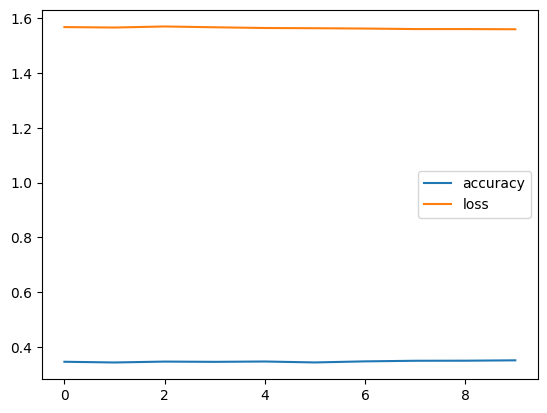

In [62]:
pd.DataFrame(history.history).plot()

In [63]:
pred =model_lstm.predict(x_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [64]:
pred

array([[0.25579688, 0.1305333 , 0.09227056, 0.03545963, 0.11546768,
        0.37047207],
       [0.30309772, 0.13110554, 0.07640131, 0.03191311, 0.12324593,
        0.33423638],
       [0.33761242, 0.14114931, 0.05545826, 0.02655594, 0.13646585,
        0.30275813],
       ...,
       [0.30024448, 0.15532464, 0.05728472, 0.0586529 , 0.12033663,
        0.3081567 ],
       [0.2830897 , 0.14049555, 0.07695498, 0.02882512, 0.12794402,
        0.3426906 ],
       [0.32350856, 0.14042288, 0.06051413, 0.02887938, 0.13149416,
        0.31518093]], dtype=float32)

In [66]:
index_class =np.argmax(pred, axis=1)

In [70]:
index_class[0:10]

array([5, 5, 0, 0, 5, 0, 0, 5, 0, 5], dtype=int64)

In [69]:
y_test[0:10]

array([5, 5, 0, 5, 0, 4, 0, 5, 5, 4])